In [3]:
%load_ext autoreload
%autoreload 2

import json
import rootutils
from dotenv import load_dotenv

root = rootutils.setup_root(search_from='..', indicator="pyproject.toml", pythonpath=True, cwd=True)
print(f"Root directory: {root}")
print(f".env file path: {root / '.env'}")
load_dotenv(dotenv_path= root / ".env")

Root directory: /Users/snopoff/Documents/Research/LLMxM2
.env file path: /Users/snopoff/Documents/Research/LLMxM2/.env


True

## The whole dataset

In [34]:
with open(root/"data/processed/realmathbenchmark_full_preprocessed_unified_2026-05-07-20-14.json", "r") as f:
    data = json.load(f)

meta, problems = data["meta"]["totals"], data["results"]
no_error_problems = [p for p in problems if "error" not in p["llm"]]

### Split by complexity and type

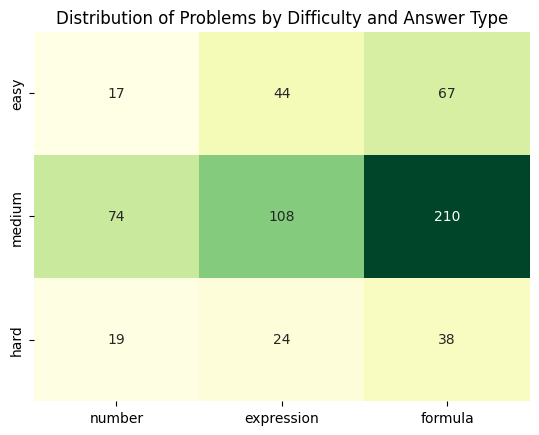

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

distribution_per_difficulty_and_answer = pd.DataFrame(
    [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
    index=['easy', 'medium', 'hard'],
    columns=['number', 'expression', 'formula']
)

problems_by_difficulty = {}
problems_by_type = {}

for difficulty in distribution_per_difficulty_and_answer.index:
    problems_by_difficulty[difficulty] = list(filter(lambda problem: problem["llm"]["difficulty"] == difficulty, no_error_problems))

for answer_type in distribution_per_difficulty_and_answer.columns:
    problems_by_type[answer_type] = list(filter(lambda problem: problem["llm"]["answer_type"] == answer_type, no_error_problems))

for difficulty in distribution_per_difficulty_and_answer.index:
    for answer_type in distribution_per_difficulty_and_answer.columns:
        distribution_per_difficulty_and_answer.loc[difficulty, answer_type] = len([
            problem for problem in problems_by_difficulty[difficulty] if problem in problems_by_type[answer_type]
        ])

ax = sns.heatmap(distribution_per_difficulty_and_answer, annot=True, fmt="d", cmap="YlGn", cbar=False)
ax.set_title("Distribution of Problems by Difficulty and Answer Type")
plt.show()

Text(0.5, 1.0, 'Median Length of (Original) Question by Difficulty and Answer Type')

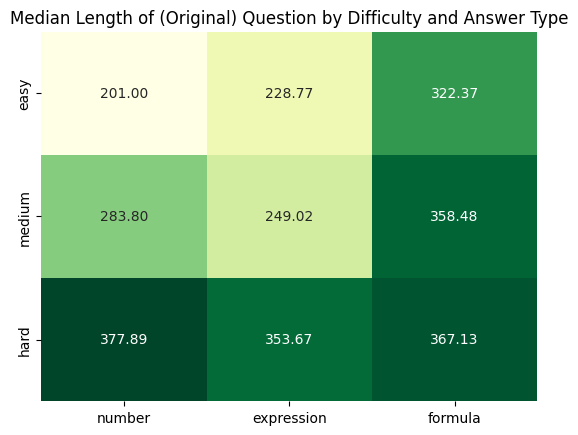

In [40]:
median_length_of_original_question_per_difficulty_and_answer = pd.DataFrame(
    [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]],
    index=['easy', 'medium', 'hard'],
    columns=['number', 'expression', 'formula']
)

for difficulty in median_length_of_original_question_per_difficulty_and_answer.index:
    for answer_type in median_length_of_original_question_per_difficulty_and_answer.columns:
        median_length_of_original_question_per_difficulty_and_answer.loc[difficulty, answer_type] = sum([
            len(problem["question"])
            for problem in problems_by_difficulty[difficulty]
            if problem in problems_by_type[answer_type]
        ]) / distribution_per_difficulty_and_answer.loc[difficulty, answer_type]

ax = sns.heatmap(median_length_of_original_question_per_difficulty_and_answer, annot=True, fmt=".2f", cmap="YlGn", cbar=False)
ax.set_title("Median Length of (Original) Question by Difficulty and Answer Type")

Text(0.5, 1.0, 'Median Length of (Revised) Question by Difficulty and Answer Type')

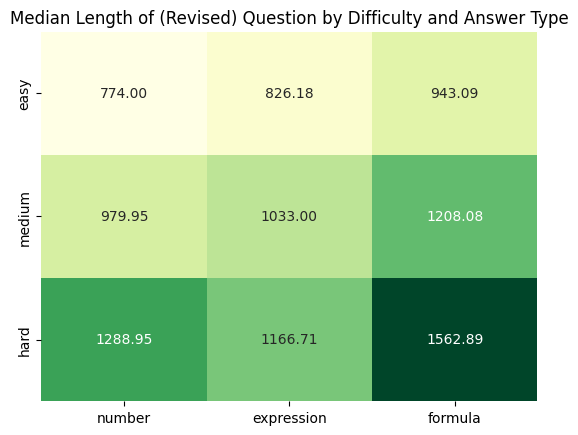

In [41]:
median_length_of_revised_question_per_difficulty_and_answer = pd.DataFrame(
    [[0., 0., 0.], [0., 0., 0.], [0., 0., 0.]],
    index=['easy', 'medium', 'hard'],
    columns=['number', 'expression', 'formula']
)

for difficulty in median_length_of_revised_question_per_difficulty_and_answer.index:
    for answer_type in median_length_of_revised_question_per_difficulty_and_answer.columns:
        median_length_of_revised_question_per_difficulty_and_answer.loc[difficulty, answer_type] = sum([
            len(problem["llm"]["revised_question"])
            for problem in problems_by_difficulty[difficulty]
            if problem in problems_by_type[answer_type]
        ]) / distribution_per_difficulty_and_answer.loc[difficulty, answer_type]

ax = sns.heatmap(median_length_of_revised_question_per_difficulty_and_answer, annot=True, fmt=".2f", cmap="YlGn", cbar=False)
ax.set_title("Median Length of (Revised) Question by Difficulty and Answer Type")

### Save datasets

In [45]:
for difficulty in problems_by_difficulty:
    print(f"{difficulty}: {len(problems_by_difficulty[difficulty])} problems")
    json.dump(problems_by_difficulty[difficulty], open(root/f"data/processed/problems_by_difficulty_{difficulty}.json", "w"), indent=4)

for answer_type in problems_by_type:
    print(f"{answer_type}: {len(problems_by_type[answer_type])} problems")
    json.dump(problems_by_type[answer_type], open(root/f"data/processed/problems_by_answer_type_{answer_type}.json", "w"), indent=4)

easy: 128 problems
medium: 392 problems
hard: 81 problems
number: 110 problems
expression: 176 problems
formula: 315 problems


## Normalized dataset

In [68]:
with open(root/"data/processed/normalized_problems.json", "r") as f:
    normalized_problems = json.load(f)

normalized_problems_by_difficulty = {}
normalized_problems_by_type = {}

for key, value in problems_by_difficulty.items():
    normalized_problems_by_difficulty[key] = [problem for problem in normalized_problems if problem["id"] in [p["id"] for p in value]]

for key, value in problems_by_type.items():
    normalized_problems_by_type[key] = [problem for problem in normalized_problems if problem["id"] in [p["id"] for p in value]]

In [69]:
print("Problems by difficulty (normalized):")
for difficulty in normalized_problems_by_difficulty:
    print(f"{difficulty}: {len(normalized_problems_by_difficulty[difficulty])} problems")
    if len(normalized_problems_by_difficulty[difficulty]) > 0:
        json.dump(normalized_problems_by_difficulty[difficulty], open(root/f"data/processed/normalized_problems_by_difficulty_{difficulty}.json", "w"), indent=4)

print("\nProblems by answer type (normalized):")
for answer_type in normalized_problems_by_type:
    print(f"{answer_type}: {len(normalized_problems_by_type[answer_type])} problems")
    if len(normalized_problems_by_type[answer_type]) > 0:
        json.dump(normalized_problems_by_type[answer_type], open(root/f"data/processed/normalized_problems_by_type_{answer_type}.json", "w"), indent=4)

Problems by difficulty (normalized):
easy: 0 problems
medium: 179 problems
hard: 40 problems

Problems by answer type (normalized):
number: 93 problems
expression: 126 problems
formula: 0 problems


In [ ]:
with open(root/"outputs/generate_predictions/predictions_2026-05-15-02-29-07-769260.jsonl", "r") as f:
    no_tool_deepseekv32 = [json.loads(line) for line in f]

with open(root/"data/results/predictions_no_tool_deepseekv32_medium_hard_number_expression.json", "w") as f:
    json.dump(no_tool_deepseekv32, f, indent=4)

In [76]:
answers_by_difficulty = {}
answers_by_type = {}

for difficulty in normalized_problems_by_difficulty:
    answers_by_difficulty[difficulty] = [
        answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]
    ]

for answer_type in normalized_problems_by_type:
    answers_by_type[answer_type] = [
        answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_type[answer_type]]
    ]

print("Answers by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"  {difficulty}: {len(answers)}")
    with open(root/f"data/results/predictions_no_tool_deepseekv32_{difficulty}_number_expression.json", "w") as f:
        json.dump(answers, f, indent=4)

print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"  {answer_type}: {len(answers)}")
    with open(root/f"data/results/predictions_no_tool_deepseekv32_medium_hard_{answer_type}.json", "w") as f:
        json.dump(answers, f, indent=4)

Answers by difficulty:
  easy: 0
  medium: 179
  hard: 40

Answers by answer type:
  number: 93
  expression: 126
  formula: 0


## Comparison DeepSeek No Tool

In [78]:
from src.benchmark.compare_predictions import compare_predictions, ComparePredictionsConfig

compare_predictions_config = ComparePredictionsConfig(
    root/"data/results/predictions_no_tool_deepseekv32_medium_hard_number_expression.json",
    summary_path=root/"data/results/comparison/comparison_no_tool_deepseekv32_medium_hard_number_expression.json")

compare_predictions(compare_predictions_config)

{'rows': 219,
 'accuracy': 0.223744,
 'correct': 49,
 'incorrect': 170,
 'exact_correct': 44,
 'symbolic_correct': 5,
 'missing_prediction_rows': 7,
 'missing_reference_rows': 0,
 'timed_out_rows': 0,
 'malformed_rows_skipped': 0,
 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/predictions_no_tool_deepseekv32_medium_hard_number_expression.json',
 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/predictions_no_tool_deepseekv32_medium_hard_number_expression_comparison_2026-05-16-15-36.jsonl',
 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/comparison/comparison_no_tool_deepseekv32_medium_hard_number_expression.json',
 'per_row_timeout_sec': 2.0,
 'prediction_sympy_fields': ['model_sympy_answer',
  'predicted_sympy_answer',
  'sympy_answer'],
 'reference_sympy_fields': ['ground_truth_sympy_answer',
  'reference_sympy_answer',
  'sympy_answer']}

In [97]:
print("Comparison by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"\n{difficulty}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/no_tool/predictions_no_tool_deepseekv32_{difficulty}_number_expression.json",
        summary_path=root/f"data/results/deepseek/no_tool/comparison/comparison_no_tool_deepseekv32_{difficulty}_number_expression.json")
    print(compare_predictions(compare_predictions_config))


print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"\n{answer_type}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/no_tool/predictions_no_tool_deepseekv32_medium_hard_{answer_type}.json",
        summary_path=root/f"data/results/deepseek/no_tool/comparison/comparison_no_tool_deepseekv32_medium_hard_{answer_type}.json")
    print(compare_predictions(compare_predictions_config))

Comparison by difficulty:

easy
  No answers to compare.

medium
  No answers to compare.

hard
{'rows': 40, 'accuracy': 0.2, 'correct': 8, 'incorrect': 32, 'exact_correct': 8, 'symbolic_correct': 0, 'missing_prediction_rows': 2, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/predictions_no_tool_deepseekv32_hard_number_expression.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/predictions_no_tool_deepseekv32_hard_number_expression_comparison_2026-05-16-20-49.jsonl', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/no_tool/comparison/comparison_no_tool_deepseekv32_hard_number_expression.json', 'per_row_timeout_sec': 2.0, 'prediction_sympy_fields': ['model_sympy_answer', 'predicted_sympy_answer', 'sympy_answer'], 'reference_sympy_fields': ['ground_truth_sympy_answer', 'reference_sympy_answer', 's

In [103]:
no_tool_deepseekv32_hard_number = [
    answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty["hard"]] and answer["id"] in [p["id"] for p in normalized_problems_by_type["number"]]
    ]

print(f"Number of hard problems with number answers: {len(no_tool_deepseekv32_hard_number)}")
json.dump(no_tool_deepseekv32_hard_number, open(root/f"data/results/predictions_no_tool_deepseekv32_hard_number.json", "w"), indent=4)

no_tool_deepseekv32_hard_expression = [
    answer for answer in no_tool_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty["hard"]] and answer["id"] in [p["id"] for p in normalized_problems_by_type["expression"]]
    ]
print(f"Number of hard problems with expression answers: {len(no_tool_deepseekv32_hard_expression)}")
json.dump(no_tool_deepseekv32_hard_expression, open(root/f"data/results/predictions_no_tool_deepseekv32_hard_expression.json", "w"), indent=4)
print("\nComparison for hard problems with number answers:")
compare_predictions_config = ComparePredictionsConfig(
    root/f"data/results/predictions_no_tool_deepseekv32_hard_number.json",
    summary_path=root/f"data/results/comparison/comparison_no_tool_deepseekv32_hard_number.json")
print(compare_predictions(compare_predictions_config))
print("\nComparison for hard problems with expression answers:")
compare_predictions_config = ComparePredictionsConfig(
    root/f"data/results/predictions_no_tool_deepseekv32_hard_expression.json",
    summary_path=root/f"data/results/comparison/comparison_no_tool_deepseekv32_hard_expression.json")
print(compare_predictions(compare_predictions_config))

Number of hard problems with number answers: 19
Number of hard problems with expression answers: 21

Comparison for hard problems with number answers:
{'rows': 19, 'accuracy': 0.368421, 'correct': 7, 'incorrect': 12, 'exact_correct': 7, 'symbolic_correct': 0, 'missing_prediction_rows': 0, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/predictions_no_tool_deepseekv32_hard_number.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/predictions_no_tool_deepseekv32_hard_number_comparison_2026-05-16-20-52.jsonl', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/comparison/comparison_no_tool_deepseekv32_hard_number.json', 'per_row_timeout_sec': 2.0, 'prediction_sympy_fields': ['model_sympy_answer', 'predicted_sympy_answer', 'sympy_answer'], 'reference_sympy_fields': ['ground_truth_sympy_answer', 'reference_sympy_answer', 'sympy_answer']}

Comparis

## Comparison DeepSeek with Sage

In [88]:
with open(root/"data/results/deepseek/tool/predictions_sage_deepseekv32_hard_number_expression.json", "r") as f:
    sage_deepseekv32 = json.load(f)

In [89]:
answers_by_difficulty = {}
answers_by_type = {}

for difficulty in normalized_problems_by_difficulty:
    answers_by_difficulty[difficulty] = [
        answer for answer in sage_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_difficulty[difficulty]]
    ]

for answer_type in normalized_problems_by_type:
    answers_by_type[answer_type] = [
        answer for answer in sage_deepseekv32 if answer["id"] in [p["id"] for p in normalized_problems_by_type[answer_type]]
    ]

print("Answers by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"  {difficulty}: {len(answers)}")
    if len(answers) == 0:
        print("  No answers to save.")
        continue
    with open(root/f"data/results/predictions_sage_deepseekv32_{difficulty}_number_expression.json", "w") as f:
        json.dump(answers, f, indent=4)

print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"  {answer_type}: {len(answers)}")
    if len(answers) == 0:
        print("  No answers to save.")
        continue
    with open(root/f"data/results/predictions_sage_deepseekv32_medium_hard_{answer_type}.json", "w") as f:
        json.dump(answers, f, indent=4)

Answers by difficulty:
  easy: 0
  No answers to save.
  medium: 0
  No answers to save.
  hard: 40

Answers by answer type:
  number: 19
  expression: 21
  formula: 0
  No answers to save.


In [92]:
print("Comparison by difficulty:")
for difficulty, answers in answers_by_difficulty.items():
    print(f"\n{difficulty}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/tool/predictions_sage_deepseekv32_{difficulty}_number_expression.json",
        summary_path=root/f"data/results/deepseek/tool/comparison/comparison_sage_deepseekv32_{difficulty}_number_expression.json")
    print(compare_predictions(compare_predictions_config))


print("\nAnswers by answer type:")
for answer_type, answers in answers_by_type.items():
    print(f"\n{answer_type}")
    if len(answers) == 0:
        print("  No answers to compare.")
        continue
    compare_predictions_config = ComparePredictionsConfig(
        root/f"data/results/deepseek/tool/predictions_sage_deepseekv32_medium_hard_{answer_type}.json",
        summary_path=root/f"data/results/deepseek/tool/comparison/comparison_sage_deepseekv32_medium_hard_{answer_type}.json")
    print(compare_predictions(compare_predictions_config))

Comparison by difficulty:

easy
  No answers to compare.

medium
  No answers to compare.

hard
{'rows': 40, 'accuracy': 0.3, 'correct': 12, 'incorrect': 28, 'exact_correct': 12, 'symbolic_correct': 0, 'missing_prediction_rows': 2, 'missing_reference_rows': 0, 'timed_out_rows': 0, 'malformed_rows_skipped': 0, 'input_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/predictions_sage_deepseekv32_hard_number_expression.json', 'output_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/predictions_sage_deepseekv32_hard_number_expression_comparison_2026-05-16-20-41.jsonl', 'summary_path': '/Users/snopoff/Documents/Research/LLMxM2/data/results/deepseek/tool/comparison/comparison_sage_deepseekv32_hard_number_expression.json', 'per_row_timeout_sec': 2.0, 'prediction_sympy_fields': ['model_sympy_answer', 'predicted_sympy_answer', 'sympy_answer'], 'reference_sympy_fields': ['ground_truth_sympy_answer', 'reference_sympy_answer', 'sympy_answer']}

